In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Preparation:

In [85]:
# load dataset
data = pd.read_excel("heart_disease.xlsx", sheet_name='Heart_disease')
data


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [86]:
data.shape

(908, 13)

### 2. Exploratory Data Analysis (EDA): 

In [87]:
#checking null values
data.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [88]:
data.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [89]:
# skewness
data['oldpeak'].skew()

np.float64(1.0217090718797428)

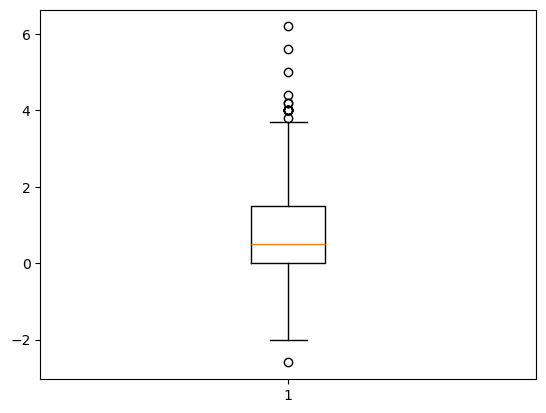

In [90]:
# finding outliers
plt.boxplot(data['oldpeak'].dropna())
plt.show()

In [91]:
data['oldpeak'].nunique()

53

In [92]:
# filling null values
median = data['oldpeak'].median()
data['oldpeak'] = data['oldpeak'].fillna(median)

In [93]:
data.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

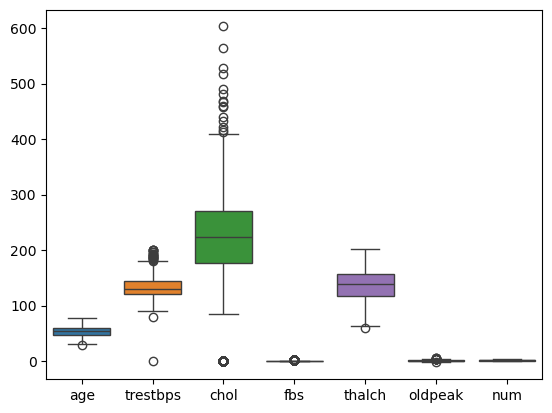

In [94]:
# finding outliers 
sns.boxplot(data)
plt.show()

In [95]:
# handling outliers

num_cols = data.select_dtypes(include = np.number).columns

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR =Q3 - Q1
    print(col ,IQR)

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    print('lower : ',lower)
    print('upper : ',upper)
    print('__________')

    data = data[(data[col]>=lower) & (data[col] <=upper)]
    data

age 12.25
lower :  29.375
upper :  78.375
__________
trestbps 24.0
lower :  84.0
upper :  180.0
__________
chol 93.0
lower :  37.5
upper :  409.5
__________
thalch 40.0
lower :  60.0
upper :  220.0
__________
oldpeak 1.5
lower :  -2.25
upper :  3.75
__________
num 1.0
lower :  -1.5
upper :  2.5
__________


In [96]:
# sns.boxplot(data)
# plt.show()

In [97]:
data.shape

(617, 13)

In [98]:
#Unique values

obj_cols = data.select_dtypes(include='object').columns

for col in obj_cols:
    print(col, ":", data[col].unique())


sex : ['Male' 'Female']
cp : ['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']
restecg : ['lv hypertrophy' 'normal' 'st-t abnormality']
exang : [False True 'FALSE' 'TURE']
slope : ['downsloping' 'flat' 'upsloping']
thal : ['fixed defect' 'normal' 'reversable defect']


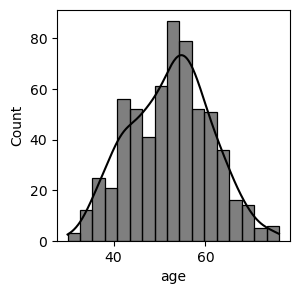

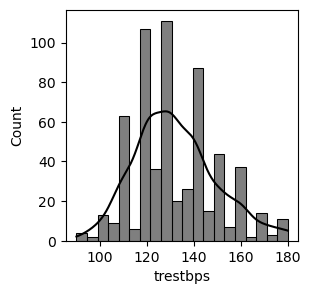

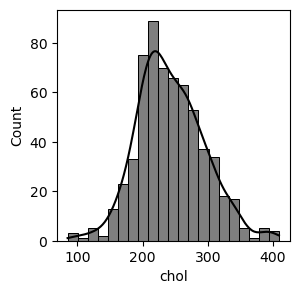

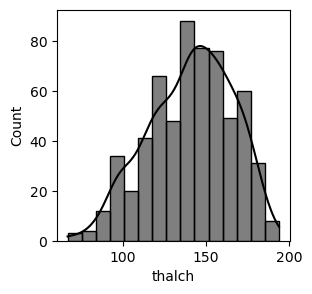

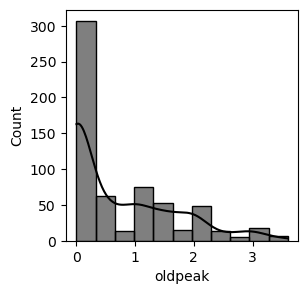

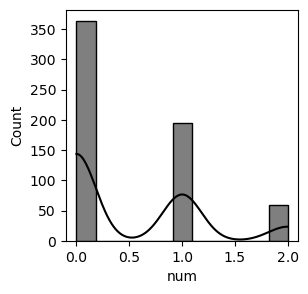

In [99]:
# hist plot
num_col = data.select_dtypes(include='number').columns
for col in num_col:
    plt.figure(figsize=(3,3))
    plt.xlabel(col)
    sns.histplot(data[col],kde=True, color='k')
    plt.show()
    

<Axes: >

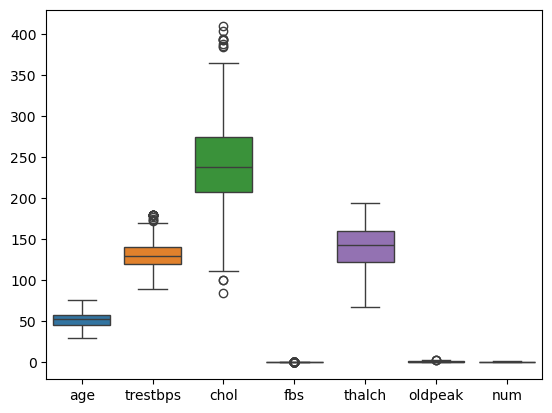

In [100]:
sns.boxplot(data)

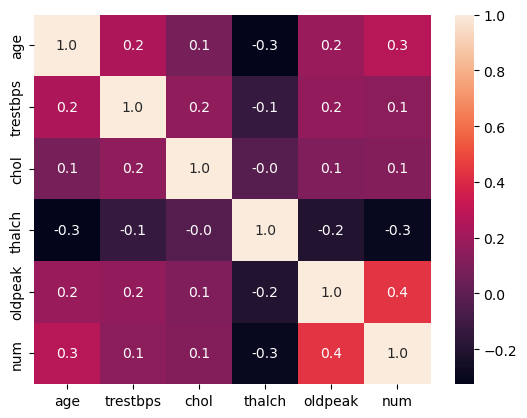

In [101]:
corr = data.select_dtypes(include=['int64', 'float']).corr()

sns.heatmap(corr , annot=True, fmt='.1f')
plt.show()

### 3. Feature Engineering:

In [102]:
# encoding 
data['sex'] = data['sex'].map({'Male': 1, 'Female': 0})
data['fbs'] = data['fbs'].map({True: 1, False: 0})


In [103]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,typical angina,145,233,1,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,1,atypical angina,135,203,0,normal,132,False,0.0,flat,fixed defect,0
2,57,1,asymptomatic,140,192,0,normal,148,False,0.4,flat,fixed defect,0
3,52,1,typical angina,118,186,0,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,1,asymptomatic,110,201,0,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,72,1,asymptomatic,160,213,1,lv hypertrophy,130,False,1.5,upsloping,fixed defect,2
764,58,1,non-anginal,150,219,0,st-t abnormality,118,True,0.0,downsloping,fixed defect,2
765,58,1,non-anginal,150,219,0,st-t abnormality,118,True,0.0,downsloping,fixed defect,2
767,58,1,non-anginal,158,232,0,st-t abnormality,138,TURE,0.5,downsloping,normal,2


In [104]:
# encoding 
data = pd.get_dummies(data, drop_first=True).astype(int)


In [105]:
data

,age,sex,trestbps,chol,fbs,thalch,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145,233,1,150,2,0,0,0,1,0,0,0,0,0,0,0,0,0
1,41,1,135,203,0,132,0,0,1,0,0,1,0,0,0,0,1,0,0,0
2,57,1,140,192,0,148,0,0,0,0,0,1,0,0,0,0,1,0,0,0
3,52,1,118,186,0,190,0,0,0,0,1,0,0,0,0,0,1,0,0,0
4,57,1,110,201,0,126,1,0,0,0,0,1,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,72,1,160,213,1,130,1,2,0,0,0,0,0,0,0,0,0,1,0,0
764,58,1,150,219,0,118,0,2,0,1,0,0,1,1,0,0,0,0,0,0
765,58,1,150,219,0,118,0,2,0,1,0,0,1,1,0,0,0,0,0,0
767,58,1,158,232,0,138,0,2,0,1,0,0,1,0,0,1,0,0,1,0


### 4. Decision Tree Classification:

In [106]:
# split data
X = data.drop("num", axis=1)
y = data["num"]


In [107]:
from sklearn.model_selection import train_test_split

In [108]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((493, 19), (124, 19), (493,), (124,))

In [109]:
from sklearn.tree import DecisionTreeClassifier

In [110]:
# build model
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [111]:
# evaluation of model

from sklearn.metrics import confusion_matrix, classification_report

In [112]:
y_pred = model.predict(X_train)

In [113]:
cm = confusion_matrix(y_train, y_pred)
cm
# plt.figure(figsize=(3,3))
# sns.heatmap(cm, annot=True, fmt='.2f')

array([[250,  35,   3],
       [ 60, 101,   2],
       [ 16,  20,   6]])

In [114]:
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.87      0.81       288
           1       0.65      0.62      0.63       163
           2       0.55      0.14      0.23        42

    accuracy                           0.72       493
   macro avg       0.65      0.54      0.56       493
weighted avg       0.71      0.72      0.70       493



In [115]:
y_pred = model.predict(X_test)

In [116]:
cm = confusion_matrix(y_test,y_pred)
cm
# plt.figure(figsize=(3,3))
# sns.heatmap(cm, annot=True, fmt='.2f')

array([[66,  9,  1],
       [15, 16,  0],
       [ 8,  8,  1]])

In [117]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80        76
           1       0.48      0.52      0.50        31
           2       0.50      0.06      0.11        17

    accuracy                           0.67       124
   macro avg       0.58      0.48      0.47       124
weighted avg       0.64      0.67      0.63       124



In [118]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)

roc_auc_score(y_test, y_prob, multi_class='ovr')


0.7433714924408606

### 5. Hyperparameter Tuning:

In [119]:
# hyper parameter tunning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2,3,4,5,6,7,8,9,10,15, None],
    'min_samples_split': [2,3,4, 5,6,7,8,9, 10],
    'min_samples_leaf': [1,2,3,4],
    'criterion': ['gini', 'entropy']
}


In [120]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


,estimator,DecisionTreeC...r(max_depth=3)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [121]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 6}
Best Score: 0.697629354772212


### 6. Model Evaluation and Analysis:

In [122]:
best_model = grid_search.best_estimator_
best_model

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,6
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [123]:
y_pred = model.predict(X_test)

In [124]:
cm = confusion_matrix(y_test,y_pred)
cm
# plt.figure(figsize=(3,3))
# sns.heatmap(cm, annot=True, fmt='.2f')

array([[66,  9,  1],
       [15, 16,  0],
       [ 8,  8,  1]])

In [125]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80        76
           1       0.48      0.52      0.50        31
           2       0.50      0.06      0.11        17

    accuracy                           0.67       124
   macro avg       0.58      0.48      0.47       124
weighted avg       0.64      0.67      0.63       124



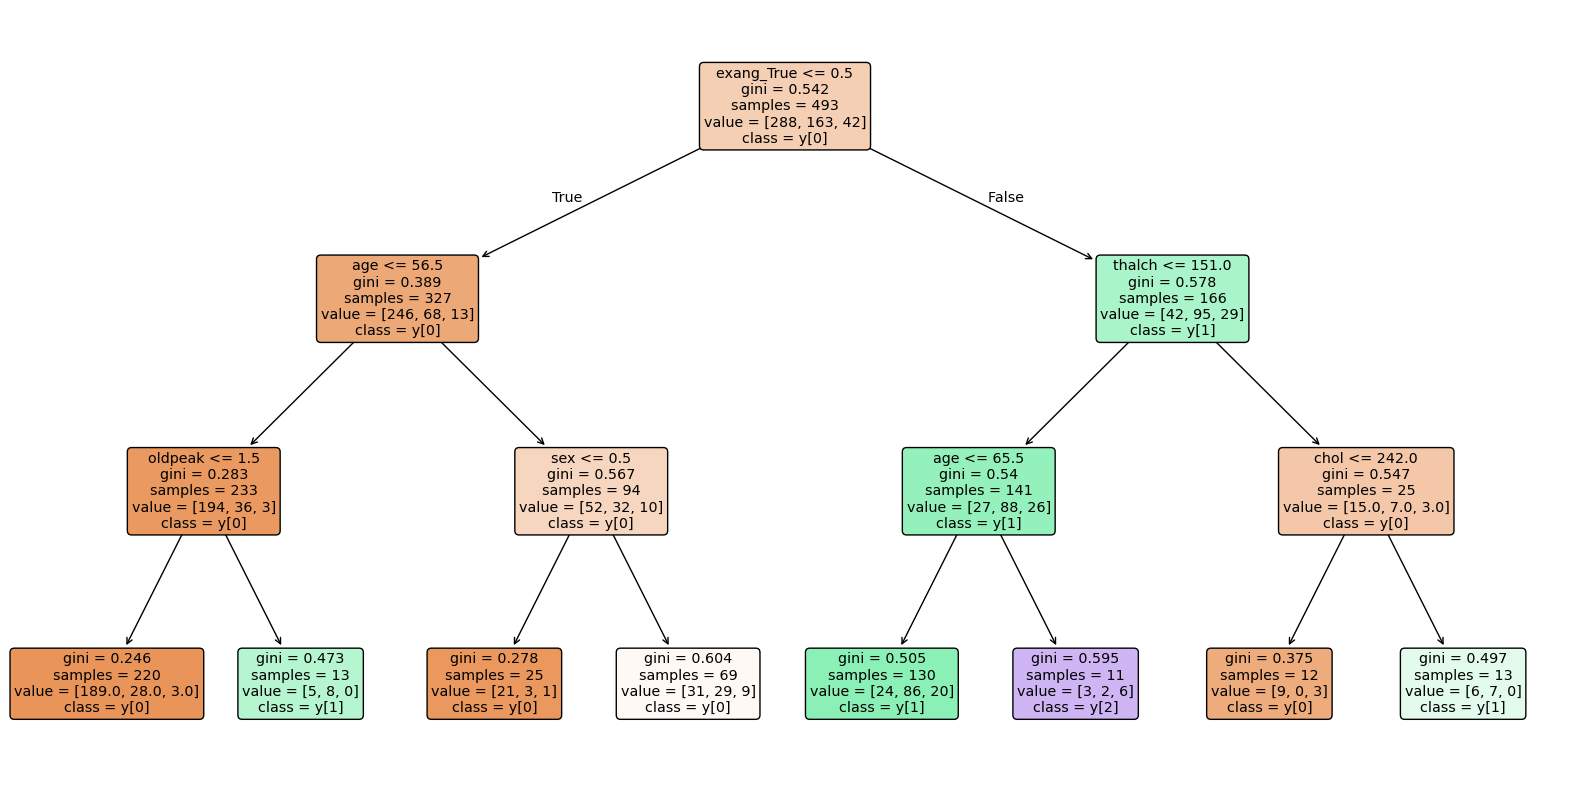

In [131]:
# ploting the tree

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(model,
          feature_names=X.columns,
          class_names=True,   # or provide class labels list
          filled=True,
          rounded=True)

plt.show()


### interview questions 